# Chicken-Wing-Index 🍗
### A billion wings on one Sunday — so can you trade the Super Bowl on Wingstop?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Super Bowl bump?: Busted](https://img.shields.io/badge/Super_Bowl_bump%3F-Busted-8b949e?style=flat-square)

The story is irresistible: Americans eat about **1.4 billion chicken wings** on Super Bowl Sunday, and Wingstop (`WING`) is the pure-play wing chain — *the* "Super-Bowl stock." Surely you buy it into the early-February game and ride the wing frenzy? We checked every month of WING since its 2015 IPO. The answer is no — and the reason is a lesson in how one lucky month fools everybody.

> **Plain-language layer.** The HAC t-stats, the placebo, the bootstrap CI and the timer math are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Not investment advice. Every chart is generated by the code beside it; the cell banners say whether it is the real WING tape or the offline synthetic control.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (chicken_wing_index/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from chicken_wing_index import data, strategy as st

# Cache-first real tape; fall back to the synthetic NULL control OFFLINE and banner which tape we show.
try:
    from quantlab import repro
    d = repro.as_of(data.fetch_data())   # cache-first (examples/verify.py --fetch)
    if d.empty:
        raise RuntimeError("cache miss")
    TAPE = "REAL  (WING monthly, 2015-07..2026-05, 131 months, fp 5742cb7dc999)"
except Exception as e:
    d, _ = data.synthetic_world(superbowl_premium=0.0, seed=726)  # the NULL synthetic world
    TAPE = f"SYNTHETIC NULL control (offline fallback: {e}) -- NOT the real tape"
print("TAPE:", TAPE)
rf    = d["tbill"]
timer = st.superbowl_timer(d["wing"], tbill=rf)
net   = st.apply_costs(timer, n_trades_per_year=2, cost_bps_one_way=10)
bh    = st.buy_hold(d["wing"])
ms    = st.month_stats(d["wing"])
win   = st.superbowl_window_test(d["wing"])
alpha = st.window_alpha_vs_market(d["wing"], d["spy"])


TAPE: REAL  (WING monthly, 2015-07..2026-05, 131 months, fp 5742cb7dc999)


## The answer first 🎯

| The claim | The data (WING, 2015–2026, 131 months, 11 Januaries) |
|---|---|
| "Wing demand spikes into the game, so buy WING" | The January-window-vs-rest spread is **+5.1%/mo, t = 1.62** — a coin flip, CI **[−0.3%, +10.4%]**. |
| "January is the tell" | January's raw **+7.2% (t = 2.52)** is one snooped month of twelve — and **off-thesis November is *stronger* (t = 2.70)**. |
| "Trade it with a calendar rule" | The long-January timer's Sharpe 0.63 only *looks* to beat buy-and-hold's 0.57 by sitting in cash — it gives up **half of WING's 20.7% CAGR**. |
| "The Super Bowl itself" | **February — the actual game month — is *negative* (−2.0%).** |

## 1 · The claim

Wingstop sells wings; the Super Bowl is the biggest wing-eating day of the year (the National Chicken Council pegs it at ~1.4 billion wings over the weekend). So the folklore: **wing demand ramps into the early-February game, WING rallies with it, and you buy the wing stock ahead of the big game.** It shows up every winter in "Super-Bowl stocks to buy" listicles.

## 2 · So what?

If the calendar were real, you wouldn't need to forecast anything — you'd just be long WING every January (the run-up to the game) and collect a seasonal premium. WING is a liquid, widely-followed US stock, so a reliable one-month edge would be easy money. The catch: is the *average* January actually up *because of wings*, or are we just staring at one good month and a stock that happened to go up a lot anyway?

## 3 · How would we even know?

We line up every January, every February, … and ask whether each month's average return is reliably different from zero. We compare the Super-Bowl run-up window (January) against *every other month*, and put an honest confidence interval on the gap. Then the killer check — a **placebo**: we rank all twelve months, because if the Super Bowl is the cause, January should stand alone at the top. And we build the obvious calendar timer and race it against just buying and holding. **If the window's CI straddles zero, an off-thesis month out-ranks January, and the game month itself is flat, it's a mirage.**

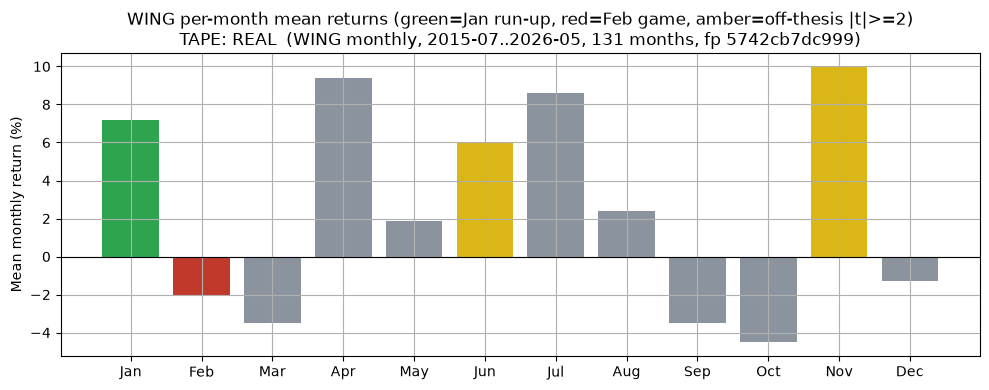

Jan run-up window: +7.20%  vs rest +2.10%
Window - rest spread: +5.10%  Welch t=1.62
February (the game month): -2.01%  <- the opposite of the thesis


In [2]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
means = [ms.loc[m,'mean']*100 for m in range(1,13)]
tstats = [ms.loc[m,'tstat'] for m in range(1,13)]
colors = []
for m in range(1,13):
    if m==1: colors.append('#2ea44f')       # the on-thesis Super-Bowl run-up window
    elif m==2: colors.append('#c0392b')     # the actual game month
    elif abs(tstats[m-1])>=2: colors.append('#dab617')  # off-thesis but 'significant'
    else: colors.append('#8b949e')
fig,ax = plt.subplots(figsize=(10,4))
ax.bar(month_names, means, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean monthly return (%)')
ax.set_title(f'WING per-month mean returns (green=Jan run-up, red=Feb game, amber=off-thesis |t|>=2)\nTAPE: {TAPE}')
plt.tight_layout(); plt.show()
print(f"Jan run-up window: {win['window_mean']*100:+.2f}%  vs rest {win['rest_mean']*100:+.2f}%")
print(f"Window - rest spread: {win['spread']*100:+.2f}%  Welch t={win['tstat']:.2f}")
print(f"February (the game month): {ms.loc[2,'mean']*100:+.2f}%  <- the opposite of the thesis")

## 4 · The teardown — let's actually look

Look at the bars. The green January bar *is* the tallest on-thesis month (**+7.2%**), and on its own it clears a naive t = 2.5 — that single number is the entire steelman. But right beside it, the **red February bar — the actual Super Bowl — is *negative***. And the tallest bar of all is an **amber** one: **November** (+10.0%, t = 2.70), which has nothing to do with wings. When you compare January against the whole rest of the year, the gap is **+5.1%/mo with t = 1.62** and a confidence interval that runs from **−0.3% to +10.4%** — it includes zero. The vivid wing story leaves no reliable fingerprint.

In [3]:
pl = st.placebo_months(d['wing'], tbill=rf)
print('12-month placebo — long-one-month timer, excess-of-T-bill Sharpe (best first):')
for m,row in pl.iterrows():
    star = '  <-- the on-thesis month' if int(m)==1 else ''
    print(f"  {month_names[int(m)-1]}: sharpe {row['sharpe']:+.2f}  t={row['tstat']:+.2f}{star}")
print(f"\nJanuary's rank among 12 months: #{list(pl.index).index(1)+1} (November is #1)")

12-month placebo — long-one-month timer, excess-of-T-bill Sharpe (best first):
  Nov: sharpe +0.66  t=+2.70
  Jan: sharpe +0.63  t=+2.52  <-- the on-thesis month
  Jun: sharpe +0.57  t=+2.25
  Apr: sharpe +0.50  t=+1.83
  Jul: sharpe +0.36  t=+1.25
  Aug: sharpe +0.15  t=+0.53
  May: sharpe +0.15  t=+0.53
  Dec: sharpe -0.17  t=-0.49
  Feb: sharpe -0.20  t=-0.58
  Mar: sharpe -0.25  t=-0.78
  Sep: sharpe -0.32  t=-1.00
  Oct: sharpe -0.33  t=-1.05

January's rank among 12 months: #2 (November is #1)


**Read it plainly.** If the Super Bowl drove WING, January would be the single best month. It isn't — an entirely unrelated month (November) beats it. That's the signature of *data-mining*: search twelve months, and the biggest one is a coin that came up heads, not a mechanism.

,cagr,sharpe,max_drawdown
Super-Bowl timer (gross),0.090,0.625,-0.113
timer (net 10bp/leg),0.087,0.607,-0.115
buy & hold WING,0.207,0.574,-0.631


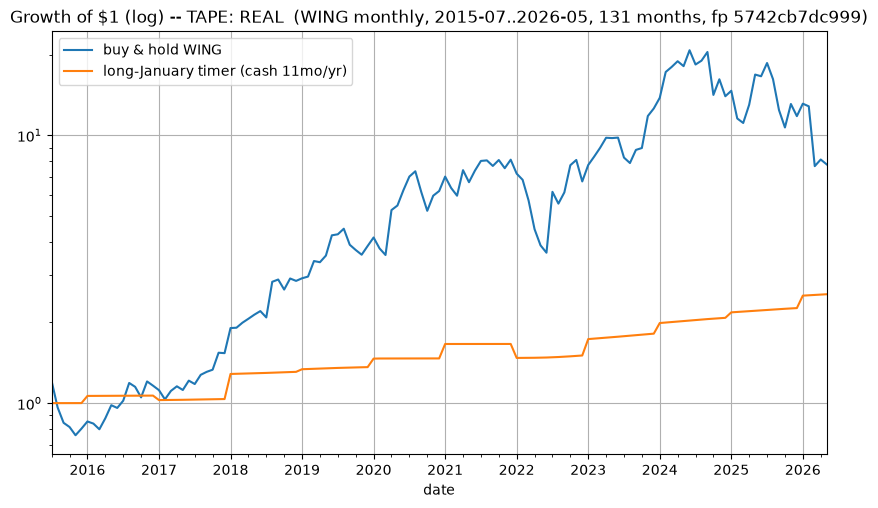

Sharpe = excess of T-bill, both legs, like-for-like


In [4]:
res = {
    'Super-Bowl timer (gross)': st.summary(timer, rf=rf),
    'timer (net 10bp/leg)':     st.summary(net,   rf=rf),
    'buy & hold WING':          st.summary(bh,    rf=rf),
}
display(pd.DataFrame(res).T[['cagr','sharpe','max_drawdown']].round(3))
eq_bh = (1+bh).cumprod(); eq_t = (1+timer).cumprod()
ax = eq_bh.plot(label='buy & hold WING', lw=1.5)
eq_t.plot(ax=ax, label='long-January timer (cash 11mo/yr)', lw=1.5)
ax.set_yscale('log'); ax.legend()
ax.set_title(f'Growth of $1 (log) -- TAPE: {TAPE}'); plt.show()
print('Sharpe = excess of T-bill, both legs, like-for-like')

**The Sharpe trap.** The timer's Sharpe (0.63) is *nominally higher* than buy-and-hold's (0.57) — but only because it sits in T-bills eleven months a year, so its volatility and drawdown collapse. It buys that lower risk by **forgoing more than half of WING's compound return** (9.0%/yr vs 20.7%/yr). That's not harvesting a wing edge; it's declining to own a great growth stock and calling the calm "risk-adjusted outperformance."

## 5 · The verdict

**Signal: None** — the window-vs-rest spread is t = 1.62 with a CI that straddles zero; January is one snooped month that off-thesis November out-ranks. **Tradability: Mirage** — the timer only "wins" on Sharpe by hiding in cash and giving up WING's growth. **Super-Bowl bump? Busted** — February, the actual game, is negative, and the January pop is half just the ordinary turn-of-year January effect.

## 6 · Could you actually trade it?

No. Buying WING every January and sitting in cash the rest of the year underperforms simply holding WING by ~12%/yr in compound terms, and the one month you pick isn't even the best. The wing demand is real — a billion wings is a real number — but it's already in the price of the wings you eat, not a date you can put in your brokerage calendar.

## 7 · Going further 🚪

Forks: (a) test WING's Super-Bowl effect at *daily* resolution in a ±2-week event window around the game date, not the calendar month; (b) look at same-store-sales in the earnings *after* the game rather than the stock before it; (c) net out the January effect with a small-cap-growth benchmark instead of SPY; (d) compare to [307 Coffee-Seasonality](../../307-coffee-seasonality/) — another vivid, true supply/demand story that makes a terrible calendar trade.